# Quijote 2LPT Rebuild Pipeline (All Seeds + One-Seed Validation)

目标：批量处理 catalog 下全部可用 seed，流程为：先生成/复用 white noise，再为每个 seed 生成并保存 psi1(z=0) 与 q_init，最后只对一个指定 seed 做 z=127/z=0 指标、功率谱和 overdensity 可视化。

## Step 1. Batch White Noise Generation (2LPTic)

In [1]:
from pathlib import Path
import shutil
import subprocess
import os
import concurrent.futures as cf

# 选择目录: 'fiducial' 或 'fiducial_LR'
CATALOG_NAME = 'fiducial'
ROOT_BASE = Path('/pscratch/sd/l/liuyh15/Quijote') / CATALOG_NAME

# white-noise 批量生成设置
BATCH_GENERATE_WN_FOR_ALL_SEEDS = True
BATCH_SKIP_EXISTING_WN = True
OVERWRITE_WN = False
RESET_WN_DIR_BEFORE_RUN = False
BATCH_WN_PARALLEL = True
BATCH_WN_MAX_WORKERS = 10

QUIJOTE_ROOT = Path('/global/homes/l/liuyh15/WorkSpace/Quijote')
LPTIC_EXE = QUIJOTE_ROOT / '2lpt' / '2LPTic'

if not LPTIC_EXE.exists():
    raise FileNotFoundError(f'2LPTic executable not found: {LPTIC_EXE}')

def _list_existing_seeds(root_base: Path):
    seeds = []
    for p in sorted(root_base.iterdir()):
        if not p.is_dir() or (not p.name.isdigit()):
            continue
        if (p / 'ICs' / '2LPT.param').exists():
            seeds.append(int(p.name))
    return seeds

def set_or_append(lines_in, key, value):
    out = []
    found = False
    for line in lines_in:
        s = line.strip()
        if s and not s.startswith('%') and s.split()[0] == key:
            out.append(f'{key}    {value}')
            found = True
        else:
            out.append(line)
    if not found:
        out.append(f'{key}    {value}')
    return out

def get_value(lines_in, key):
    for line in lines_in:
        s = line.strip()
        if not s or s.startswith('%'):
            continue
        p = s.split()
        if len(p) > 1 and p[0] == key:
            return p[1]
    return None

def resolve_resource_path(src_param, raw_value):
    p = Path(raw_value)
    if p.is_absolute() and p.exists():
        return p
    cands = [
        (src_param.parent / p).resolve(),
        (QUIJOTE_ROOT / p).resolve(),
        (QUIJOTE_ROOT / '2lpt' / p).resolve(),
        (QUIJOTE_ROOT / 'CAMB_TABLES' / p.name).resolve(),
        (QUIJOTE_ROOT / '2lpt' / 'GLASS' / p.name).resolve(),
    ]
    for c in cands:
        if c.exists():
            return c
    return cands[0]

def generate_white_noise_for_seed(seed_i: int):
    root = ROOT_BASE / str(seed_i)
    wn_dir = root / 'wn'
    ics_dir = root / 'ICs'
    src_param = ics_dir / '2LPT.param'
    dst_param = wn_dir / '2LPT_wn.param'
    white_noise_file = wn_dir / 'white_noise.npz'

    if not src_param.exists():
        raise FileNotFoundError(f'source param not found: {src_param}')

    if RESET_WN_DIR_BEFORE_RUN and wn_dir.exists():
        print(f'[cleanup][seed {seed_i}] remove {wn_dir}')
        shutil.rmtree(wn_dir)
    wn_dir.mkdir(parents=True, exist_ok=True)

    if BATCH_SKIP_EXISTING_WN and white_noise_file.exists() and dst_param.exists() and (not OVERWRITE_WN):
        print(f'[seed {seed_i}] skip: white noise exists')
        return False, white_noise_file

    # 写 white-noise-only param
    lines = src_param.read_text(encoding='utf-8').replace('\r\n', '\n').splitlines()
    lines = set_or_append(lines, 'OutputDir', str(wn_dir))
    lines = set_or_append(lines, 'FileBase', 'ics')
    lines = set_or_append(lines, 'UseWhiteNoiseInput', '0')
    lines = set_or_append(lines, 'ExportWhiteNoiseOnly', '1')
    lines = set_or_append(lines, 'WhiteNoiseFile', str(white_noise_file))

    for key in ('FileWithInputSpectrum', 'GlassFile'):
        v = get_value(lines, key)
        if v is not None:
            lines = set_or_append(lines, key, str(resolve_resource_path(src_param, v)))

    dst_param.write_text('\n'.join(lines) + '\n', encoding='utf-8')

    if OVERWRITE_WN and white_noise_file.exists():
        white_noise_file.unlink()

    cmd = [str(LPTIC_EXE), str(dst_param)]
    env = dict(os.environ)
    env['MPICH_GPU_SUPPORT_ENABLED'] = '0'
    print(f'[seed {seed_i}] run:', ' '.join(cmd))

    with subprocess.Popen(
        cmd,
        cwd=str(wn_dir),
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    ) as proc:
        if proc.stdout is not None:
            for line in proc.stdout:
                print(f'[seed {seed_i}] {line}', end='')
        rc = proc.wait()

    if rc != 0:
        raise RuntimeError(f'2LPTic failed with return code {rc} for seed={seed_i}')
    if not white_noise_file.exists():
        raise FileNotFoundError(f'white noise was not produced: {white_noise_file}')

    return True, white_noise_file

def _run_wn_seed(seed_i: int):
    row = {'seed': seed_i, 'generated': False, 'white_noise': '', 'error': ''}
    try:
        generated, wn_file = generate_white_noise_for_seed(seed_i)
        row['generated'] = bool(generated)
        row['white_noise'] = str(wn_file)
    except Exception as e:
        row['error'] = str(e)
        print(f'[seed {seed_i}] fail:', e)
    return row

# 批量生成 wn（所有已有 seeds）
if BATCH_GENERATE_WN_FOR_ALL_SEEDS:
    seeds = _list_existing_seeds(ROOT_BASE)
    print(f'[batch wn] catalog={CATALOG_NAME}, seeds={seeds}')

    wn_rows = []
    use_parallel = BATCH_WN_PARALLEL and (BATCH_WN_MAX_WORKERS > 1) and (len(seeds) > 1)

    if use_parallel:
        workers = min(BATCH_WN_MAX_WORKERS, len(seeds))
        print(f'[batch wn] parallel enabled, workers={workers}')
        with cf.ThreadPoolExecutor(max_workers=workers) as ex:
            futs = {ex.submit(_run_wn_seed, s): s for s in seeds}
            for fut in cf.as_completed(futs):
                wn_rows.append(fut.result())
    else:
        print('[batch wn] serial mode')
        for seed_i in seeds:
            wn_rows.append(_run_wn_seed(seed_i))

    wn_rows.sort(key=lambda r: r['seed'])
    wn_ok = [r for r in wn_rows if not r['error']]
    wn_fail = [r for r in wn_rows if r['error']]
    print('\n[batch wn summary]')
    print('total:', len(wn_rows), 'ok:', len(wn_ok), 'fail:', len(wn_fail))
    print('generated:', sum(int(r['generated']) for r in wn_rows), 'skipped:', len(wn_ok) - sum(int(r['generated']) for r in wn_rows))
    if wn_fail:
        print('failed seeds:', [r['seed'] for r in wn_fail])

# 仅用于后续单 seed 展示/检查，不影响上面的全 seed wn 生成
SEED = 0
ROOT = ROOT_BASE / str(SEED)
WN_DIR = ROOT / 'wn'
ICS_DIR = ROOT / 'ICs'
DST_PARAM = WN_DIR / '2LPT_wn.param'
WHITE_NOISE_FILE = WN_DIR / 'white_noise.npz'
print(f'\n[single-seed context] catalog={CATALOG_NAME}, seed={SEED}, wn={WHITE_NOISE_FILE}')

[batch wn] catalog=fiducial, seeds=[0, 1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 3, 4, 5, 6, 7, 8, 9]
[batch wn] parallel enabled, workers=10
[seed 0] skip: white noise exists
[seed 10] skip: white noise exists
[seed 1] skip: white noise exists
[seed 12] skip: white noise exists
[seed 13] skip: white noise exists
[seed 11] skip: white noise exists
[seed 16] skip: white noise exists
[seed 17] skip: white noise exists
[seed 14] skip: white noise exists
[seed 18] skip: white noise exists
[seed 4] skip: white noise exists
[seed 15] skip: white noise exists
[seed 2] skip: white noise exists
[seed 19] skip: white noise exists
[seed 3] skip: white noise exists
[seed 6] skip: white noise exists
[seed 9] skip: white noise exists
[seed 5] skip: white noise exists
[seed 7] skip: white noise exists
[seed 8] skip: white noise exists

[batch wn summary]
total: 20 ok: 20 fail: 0
generated: 0 skipped: 20

[single-seed context] catalog=fiducial, seed=0, wn=/pscratch/sd/l/liuyh15/Quijote/fiducial/0/

## Step 2. Batch Build And Save psi1(z=0) + q_init

In [2]:
from pathlib import Path
import sys
import importlib
import numpy as np

TESTS_DIR = Path('/global/homes/l/liuyh15/WorkSpace/DDDF/tests')
if str(TESTS_DIR) not in sys.path:
    sys.path.insert(0, str(TESTS_DIR))

_2LPT = importlib.import_module('2LPT')
n2 = importlib.reload(_2LPT)

BATCH_FORCE_NMESH = None
BATCH_SKIP_EXISTING_PSI_QINIT = True

def _list_existing_seeds(root_base: Path):
    seeds = []
    for p in sorted(root_base.iterdir()):
        if p.is_dir() and p.name.isdigit() and (p / 'ICs' / '2LPT.param').exists():
            seeds.append(int(p.name))
    return seeds

seed_list = _list_existing_seeds(ROOT_BASE)
print(f'[psi1/q_init batch] catalog={CATALOG_NAME}, seeds={seed_list}')

psiq_rows = []
for seed_i in seed_list:
    row = {'seed': seed_i, 'psi1_file': '', 'qinit_file': '', 'generated': False, 'error': ''}
    try:
        root_i = ROOT_BASE / str(seed_i)
        wn_dir_i = root_i / 'wn'
        tag_i = f'seed{seed_i:03d}'
        psi1_candidates = sorted(wn_dir_i.glob(f'psi1_grid_z0_{tag_i}_n*.npz'))
        qinit_candidates = sorted(wn_dir_i.glob(f'q_init_{tag_i}_n*.npz'))

        if BATCH_SKIP_EXISTING_PSI_QINIT and psi1_candidates and qinit_candidates:
            psi1_file_i = psi1_candidates[-1]
            qinit_file_i = qinit_candidates[-1]
            print(f'[seed {seed_i}] skip existing: {psi1_file_i.name}, {qinit_file_i.name}')
        else:
            paths_i = n2.discover_seed_paths(preferred_root=root_i, fallback_root=root_i)
            psi1_file_i, qinit_file_i = n2.save_psi1_and_qinit_for_seed(
                paths_i,
                force_nmesh=BATCH_FORCE_NMESH,
                output_tag=tag_i,
            )
            row['generated'] = True
            print(f'[seed {seed_i}] generated: {Path(psi1_file_i).name}, {Path(qinit_file_i).name}')

        row['psi1_file'] = str(psi1_file_i)
        row['qinit_file'] = str(qinit_file_i)
    except Exception as e:
        row['error'] = str(e)
        print(f'[seed {seed_i}] fail: {e}')
    psiq_rows.append(row)

psiq_rows.sort(key=lambda r: r['seed'])
psiq_ok = [r for r in psiq_rows if not r['error']]
psiq_fail = [r for r in psiq_rows if r['error']]

print('\n[psi1/q_init summary]')
print('total:', len(psiq_rows), 'ok:', len(psiq_ok), 'fail:', len(psiq_fail))
print('generated:', sum(int(r['generated']) for r in psiq_rows), 'reused:', len(psiq_ok) - sum(int(r['generated']) for r in psiq_rows))
if psiq_fail:
    print('failed seeds:', [r['seed'] for r in psiq_fail])

# 为后续“特定 seed 对比”提供默认 seed
if psiq_ok:
    DEFAULT_COMPARE_SEED = int(psiq_ok[0]['seed'])
    print(f'default compare seed: {DEFAULT_COMPARE_SEED}')

[psi1/q_init batch] catalog=fiducial, seeds=[0, 1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 3, 4, 5, 6, 7, 8, 9]
[seed 0] skip existing: psi1_grid_z0_seed000_n512.npz, q_init_seed000_n512.npz
[seed 1] skip existing: psi1_grid_z0_seed001_n512.npz, q_init_seed001_n512.npz
[seed 10] skip existing: psi1_grid_z0_seed010_n512.npz, q_init_seed010_n512.npz
[seed 11] skip existing: psi1_grid_z0_seed011_n512.npz, q_init_seed011_n512.npz
[seed 12] skip existing: psi1_grid_z0_seed012_n512.npz, q_init_seed012_n512.npz
[seed 13] skip existing: psi1_grid_z0_seed013_n512.npz, q_init_seed013_n512.npz
[seed 14] skip existing: psi1_grid_z0_seed014_n512.npz, q_init_seed014_n512.npz
[seed 15] skip existing: psi1_grid_z0_seed015_n512.npz, q_init_seed015_n512.npz
[seed 16] skip existing: psi1_grid_z0_seed016_n512.npz, q_init_seed016_n512.npz
[seed 17] skip existing: psi1_grid_z0_seed017_n512.npz, q_init_seed017_n512.npz
[seed 18] skip existing: psi1_grid_z0_seed018_n512.npz, q_init_seed018_n512.npz
[seed 1

## Step 3. One-Seed Validation (Metrics + Power Spectrum + Overdensity)

[timing] check globals                            step=  0.000s  total=  0.000s
[timing] filter successful seeds                  step=  0.000s  total=  0.000s
[compare] seed=0
[timing] select seed row                          step=  0.000s  total=  0.001s
[timing] resolve file paths                       step=  0.002s  total=  0.002s


[compare] GRID=512 inferred from npart=134217728
[timing] load q_init and infer GRID               step=  3.064s  total=  3.067s
[timing] reconstruct z=127 positions              step= 56.824s  total= 59.891s
[timing] compare z=127 metrics (aligned)          step=  3.384s  total= 63.275s
[timing] compare z=0 metrics (aligned)            step=  5.129s  total= 68.404s

[z=127 metrics]
{'n_match': 16777216.0,
 'p50': 0.5420123934745789,
 'p90': 0.8970777988433838,
 'p99': 1.2352708578109741,
 'pos_max': 2.270524263381958,
 'pos_rms': 0.6180528998374939}

[z=0 metrics]
{'disp_max': 37854.0,
 'disp_rms': 10113.634765625,
 'n_match': 16849173.0,
 'p50': 8820.876953125,
 'p90': 14705.9287109375,
 'p99': 20589.01953125}
[timing] z=127 aligned CIC+PKL+ratio              step= 14.224s  total= 82.627s
[timing] build z=127 ratio arrays                 step=  0.001s  total= 82.628s
[timing] load psi1 fields                         step=  6.931s  total= 89.559s
[timing] build psi2 fields            

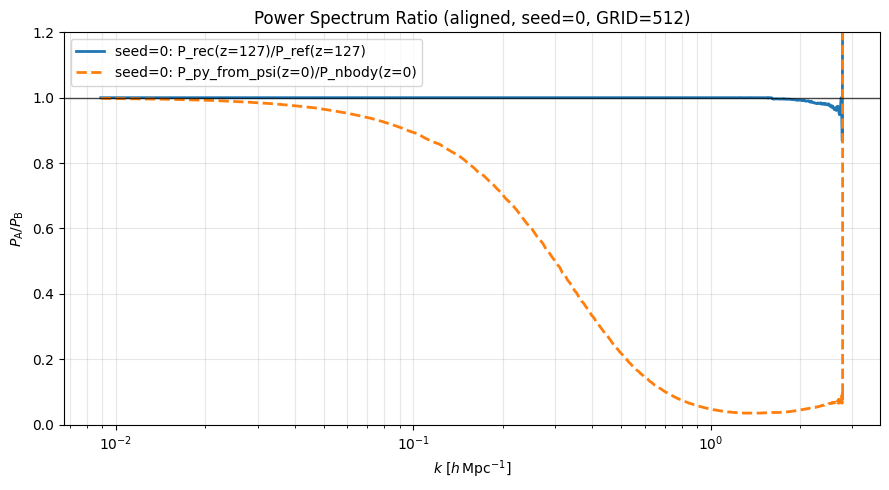

[timing] plot                                     step=  0.890s  total=163.009s


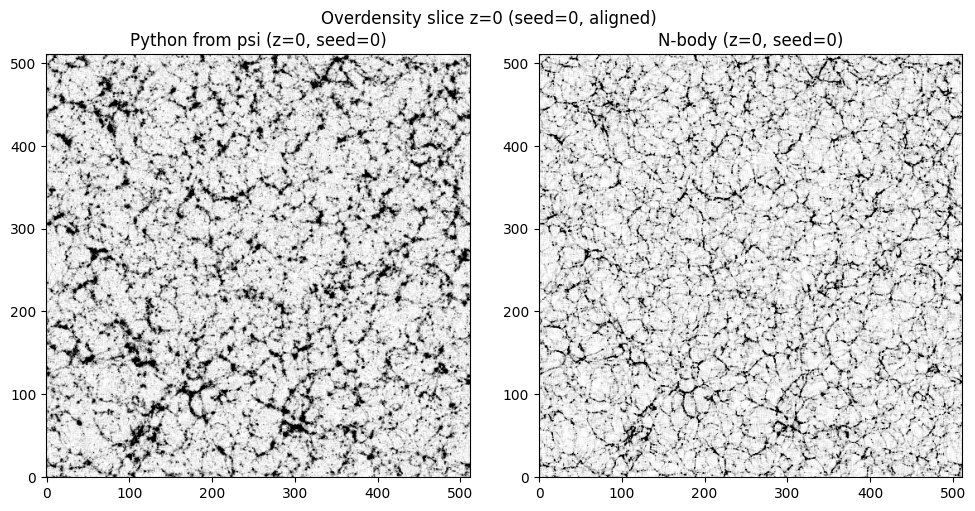

[timing] plot z=0 overdensity slices              step=  0.726s  total=163.735s
[timing] TOTAL                                   163.735s


In [5]:
from pathlib import Path
from pprint import pprint
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import Pk_library as PKL

# 对齐粒子后做比较，并输出每一步耗时。
COMPARE_SEED = None
COMPARE_MAX_FILES = 1
Z0_POWER_MAX_FILES = None
GRID = None  # None -> infer from q_init particle resolution

t_start = perf_counter()
t_prev = t_start


def log_step(name: str):
    global t_prev
    t_now = perf_counter()
    print(f"[timing] {name:<40s} step={t_now - t_prev:7.3f}s  total={t_now - t_start:7.3f}s")
    t_prev = t_now


if 'psiq_rows' not in globals():
    raise RuntimeError('psiq_rows is missing. Please run cell 5 first.')
log_step('check globals')

ok_rows = [r for r in psiq_rows if not r['error']]
if not ok_rows:
    raise RuntimeError('No successful seed in psiq_rows.')
log_step('filter successful seeds')

if COMPARE_SEED is None:
    seed_i = int(ok_rows[0]['seed'])
else:
    target = [r for r in ok_rows if int(r['seed']) == int(COMPARE_SEED)]
    if not target:
        available = sorted(int(r['seed']) for r in ok_rows)
        raise RuntimeError(f'COMPARE_SEED={COMPARE_SEED} unavailable. Available seeds: {available}')
    seed_i = int(target[0]['seed'])

row = [r for r in ok_rows if int(r['seed']) == seed_i][0]
print(f'[compare] seed={seed_i}')
log_step('select seed row')

root_i = ROOT_BASE / str(seed_i)
paths = n2.discover_seed_paths(preferred_root=root_i, fallback_root=root_i)
psi1_file = Path(row['psi1_file'])
qinit_file = Path(row['qinit_file'])
log_step('resolve file paths')

qd = np.load(qinit_file)
q_init = qd['q_init'].astype(np.float32)
npart = int(q_init.shape[0])
nmesh_guess = int(round(npart ** (1.0 / 3.0)))
if nmesh_guess ** 3 != npart:
    raise RuntimeError(f'Cannot infer cubic mesh from npart={npart}')
if GRID is None:
    GRID = nmesh_guess
print(f'[compare] GRID={GRID} inferred from npart={npart}')
log_step('load q_init and infer GRID')

recon = n2.reconstruct_z127_displacement_only(
    psi1_file=psi1_file,
    qinit_file=qinit_file,
    param_file=paths.param_file,
)
box = float(recon['box'][0])
log_step('reconstruct z=127 positions')

z127_metrics = n2.compare_z127_positions(
    recon_positions=recon['x_rec'],
    recon_ids=recon['ids'],
    ic_ref=paths.ic_ref,
    box=box,
    max_files=COMPARE_MAX_FILES,
)
log_step('compare z=127 metrics (aligned)')

z0_metrics = n2.compare_with_snapshot_z0(
    recon_positions=recon['x_rec'],
    recon_ids=recon['ids'],
    snapshot_dir=paths.snapshot_z0,
    box=box,
    max_files=COMPARE_MAX_FILES,
)
log_step('compare z=0 metrics (aligned)')

print('\n[z=127 metrics]')
pprint(z127_metrics)
print('\n[z=0 metrics]')
pprint(z0_metrics)

# Power ratio at z=127 (aligned in n2.compare_power_spectrum_z127)
pk_cmp_z127 = n2.compare_power_spectrum_z127(
    recon_positions=recon['x_rec'],
    recon_ids=recon['ids'],
    ic_ref=paths.ic_ref,
    box=box,
    max_files=COMPARE_MAX_FILES,
    grid=GRID,
)
log_step('z=127 aligned CIC+PKL+ratio')

k127 = np.asarray(pk_cmp_z127['k_h_mpc'], dtype=np.float64)
ratio127 = np.asarray(pk_cmp_z127['pk_ratio'], dtype=np.float64)
m127 = np.isfinite(ratio127) & (k127 > 0)
log_step('build z=127 ratio arrays')

# Power ratio at z=0 from psi (aligned by particle id)
psi = np.load(psi1_file)
psi1x = psi['psi1_x'].astype(np.float32)
psi1y = psi['psi1_y'].astype(np.float32)
psi1z = psi['psi1_z'].astype(np.float32)
box_local = float(np.asarray(psi['box']).ravel()[0])
log_step('load psi1 fields')

psi2x, psi2y, psi2z = n2._build_psi2_from_psi1(psi1x, psi1y, psi1z, box_local)
log_step('build psi2 fields')

if 'dplus' in psi.files:
    dplus = float(np.asarray(psi['dplus']).ravel()[0])
    scale1 = dplus
    scale2 = dplus * dplus
else:
    scale1 = 1.0
    scale2 = 1.0

disp0_particles = n2._trilinear_interp_vector(
    q_init,
    scale1 * psi1x + scale2 * psi2x,
    scale1 * psi1y + scale2 * psi2y,
    scale1 * psi1z + scale2 * psi2z,
    box_local,
)
x0_pred = np.mod(q_init + disp0_particles, np.float32(box_local)).astype(np.float32)
ids_pred = np.arange(1, q_init.shape[0] + 1, dtype=np.uint32)
log_step('interpolate + build z=0 prediction')

z0_pos, z0_ids = n2._load_hdf5_particles(paths.snapshot_z0, max_files=Z0_POWER_MAX_FILES)
log_step('load z=0 reference particles')

sel_pred, sel_z0 = n2._match_particle_ids(ids_pred, z0_ids)
log_step('align z=0 particles by ID')

k0 = np.array([], dtype=np.float64)
ratio0 = np.array([], dtype=np.float64)
m0 = np.array([], dtype=bool)
delta_pred_z0 = None
delta_ref_z0 = None

if sel_pred.size > 0:
    pred_sel = x0_pred[sel_pred]
    z0_sel = z0_pos[sel_z0]

    delta_pred_z0 = n2._paint_cic_density(pred_sel, box=box_local, grid=GRID)
    log_step('CIC paint z=0 aligned prediction')

    delta_ref_z0 = n2._paint_cic_density(z0_sel, box=box_local, grid=GRID)
    log_step('CIC paint z=0 aligned reference')

    pk_pred_obj = PKL.Pk(delta_pred_z0, box_local, axis=0, MAS='CIC', threads=16, verbose=False)
    log_step('PKL Pk z=0 aligned prediction')

    pk_ref_obj = PKL.Pk(delta_ref_z0, box_local, axis=0, MAS='CIC', threads=16, verbose=False)
    log_step('PKL Pk z=0 aligned reference')

    k0 = np.asarray(pk_ref_obj.k3D, dtype=np.float64) * 1000.0
    pk_ref0 = np.asarray(pk_ref_obj.Pk[:, 0], dtype=np.float64)
    pk_pred0 = np.asarray(pk_pred_obj.Pk[:, 0], dtype=np.float64)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio0 = np.where(pk_ref0 > 1e-30, pk_pred0 / pk_ref0, np.nan)
    m0 = np.isfinite(ratio0) & (k0 > 0)
    log_step('build z=0 aligned ratio arrays')
else:
    print('[warning] no matched particle IDs between prediction and z=0 reference')

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xscale('log')
if np.any(m127):
    ax.plot(k127[m127], ratio127[m127], lw=2.0, color='tab:blue', label=f'seed={seed_i}: P_rec(z=127)/P_ref(z=127)')
if np.any(m0):
    ax.plot(k0[m0], ratio0[m0], lw=2.0, ls='--', color='tab:orange', label=f'seed={seed_i}: P_py_from_psi(z=0)/P_nbody(z=0)')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\mathrm{A}}/P_{\mathrm{B}}$')
ax.set_ylim(0.0, 1.2)
ax.set_title(f'Power Spectrum Ratio (aligned, seed={seed_i}, GRID={GRID})')
ax.grid(alpha=0.3, which='both')
if np.any(m127) or np.any(m0):
    ax.legend()
plt.tight_layout()
plt.show()
log_step('plot')

if (delta_pred_z0 is not None) and (delta_ref_z0 is not None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    img_py = np.mean(delta_pred_z0[:1], axis=0).T
    img_nb = np.mean(delta_ref_z0[:1], axis=0).T
    axes[0].imshow(img_py, cmap='gray_r', vmin=-1, vmax=3, origin='lower')
    axes[0].set_title(f'Python from psi (z=0, seed={seed_i})')
    axes[1].imshow(img_nb, cmap='gray_r', vmin=-1, vmax=3, origin='lower')
    axes[1].set_title(f'N-body (z=0, seed={seed_i})')
    plt.suptitle(f'Overdensity slice z=0 (seed={seed_i}, aligned)')
    plt.tight_layout()
    plt.show()
    log_step('plot z=0 overdensity slices')
else:
    print(f'z=0 overdensity slice skipped for seed={seed_i}.')

print(f"[timing] TOTAL{'':<35s}{perf_counter() - t_start:7.3f}s")

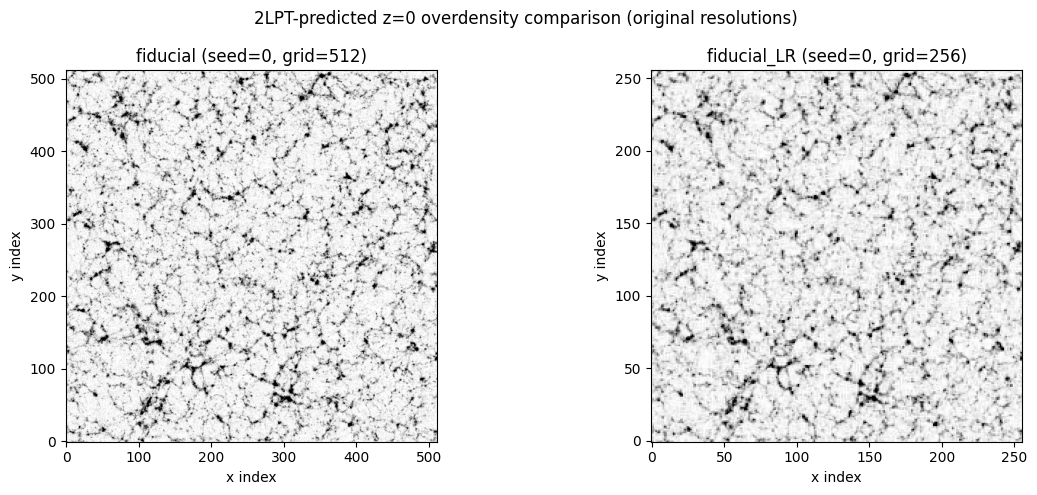

In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 比较 fiducial 与 fiducial_LR 在 seed=0 下，用 2LPT 预测得到的 z=0 overdensity。
# 注意：每个 catalog 使用各自原始粒子分辨率推断的 grid，不做重采样。
COMPARE_CATALOGS = ['fiducial', 'fiducial_LR']
COMPARE_SEED = 0

if 'n2' not in globals():
    import importlib
    _2LPT = importlib.import_module('2LPT')
    n2 = importlib.reload(_2LPT)

base_quijote = Path('/pscratch/sd/l/liuyh15/Quijote')
results = []

for catalog in COMPARE_CATALOGS:
    root_i = base_quijote / catalog / str(COMPARE_SEED)
    wn_dir = root_i / 'wn'
    tag = f'seed{COMPARE_SEED:03d}'

    psi_candidates = sorted(wn_dir.glob(f'psi1_grid_z0_{tag}_n*.npz'))
    qinit_candidates = sorted(wn_dir.glob(f'q_init_{tag}_n*.npz'))
    if (not psi_candidates) or (not qinit_candidates):
        raise FileNotFoundError(
            f'[{catalog}] missing psi1/q_init for seed={COMPARE_SEED} under {wn_dir}. '
            'Run Step 2 first to generate them.'
        )

    psi_file = psi_candidates[-1]
    qinit_file = qinit_candidates[-1]

    qd = np.load(qinit_file)
    q_init = qd['q_init'].astype(np.float32)
    npart = int(q_init.shape[0])
    grid_local = int(round(npart ** (1.0 / 3.0)))
    if grid_local ** 3 != npart:
        raise RuntimeError(f'[{catalog}] cannot infer cubic mesh from npart={npart}')

    psi = np.load(psi_file)
    psi1x = psi['psi1_x'].astype(np.float32)
    psi1y = psi['psi1_y'].astype(np.float32)
    psi1z = psi['psi1_z'].astype(np.float32)
    box_local = float(np.asarray(psi['box']).ravel()[0])

    psi2x, psi2y, psi2z = n2._build_psi2_from_psi1(psi1x, psi1y, psi1z, box_local)

    if 'dplus' in psi.files:
        dplus = float(np.asarray(psi['dplus']).ravel()[0])
        scale1 = dplus
        scale2 = dplus * dplus
    else:
        scale1 = 1.0
        scale2 = 1.0

    disp0_particles = n2._trilinear_interp_vector(
        q_init,
        scale1 * psi1x + scale2 * psi2x,
        scale1 * psi1y + scale2 * psi2y,
        scale1 * psi1z + scale2 * psi2z,
        box_local,
    )
    x0_pred = np.mod(q_init + disp0_particles, np.float32(box_local)).astype(np.float32)
    delta0 = n2._paint_cic_density(x0_pred, box=box_local, grid=grid_local)

    # 与 Step 3 保持一致，取第 0 个切片并沿一个轴平均得到 2D 可视化
    img = np.mean(delta0[:1], axis=0).T
    results.append({'catalog': catalog, 'grid': grid_local, 'img': img})

all_pixels = np.concatenate([r['img'].ravel() for r in results])
vmin = float(np.nanpercentile(all_pixels, 1.0))
vmax = float(np.nanpercentile(all_pixels, 99.0))

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    ax.imshow(r['img'], cmap='gray_r', vmin=vmin, vmax=vmax, origin='lower')
    ax.set_title(f"{r['catalog']} (seed={COMPARE_SEED}, grid={r['grid']})")
    ax.set_xlabel('x index')
    ax.set_ylabel('y index')

plt.suptitle('2LPT-predicted z=0 overdensity comparison (original resolutions)')
plt.tight_layout()
plt.show()